Objectif : Exploration des donnees, typologie des marques de cigarettes, Explication de la variable "Contenu de Monoxide de Carbon".
 

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import SequentialFeatureSelector


In [2]:
colums_names = ['brand_name', 'tar_content', 'nicotine_content', 'weight', 'carbon_monoxide_content']
cigarettes = pd.read_csv('cigarettes.csv', header=None, names=colums_names)
cigarettes.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   brand_name               25 non-null     str    
 1   tar_content              25 non-null     float64
 2   nicotine_content         25 non-null     float64
 3   weight                   25 non-null     float64
 4   carbon_monoxide_content  25 non-null     float64
dtypes: float64(4), str(1)
memory usage: 1.1 KB


Tar content (mg) 
Nicotine content (mg) 
Weight (g)
Carbon monoxide content (mg)

In [3]:
cigarettes

,brand_name,tar_content,nicotine_content,weight,carbon_monoxide_content
0,Alpine,14.1,0.86,0.9853,13.6
1,Benson&Hedges,16.0,1.06,1.0938,16.6
2,BullDurham,29.8,2.03,1.1650,23.5
3,CamelLights,8.0,0.67,0.9280,10.2
4,Carlton,4.1,0.40,0.9462,5.4
5,Chesterfield,15.0,1.04,0.8885,15.0
6,GoldenLights,8.8,0.76,1.0267,9.0
7,Kent,12.4,0.95,0.9225,12.3
8,Kool,16.6,1.12,0.9372,16.3
9,L&M,14.9,1.02,0.8858,15.4


In [4]:
cigarettes.describe()

,tar_content,nicotine_content,weight,carbon_monoxide_content
count,25.00000,25.000000,25.000000,25.000000
mean,12.21600,0.876400,0.970284,12.528000
std,5.66581,0.354058,0.087721,4.739684
min,1.00000,0.130000,0.785100,1.500000
25%,8.60000,0.690000,0.922500,10.000000
50%,12.80000,0.900000,0.957300,13.000000
75%,15.10000,1.020000,1.007000,15.400000
max,29.80000,2.030000,1.165000,23.500000


In [5]:
cigarettes.corr(numeric_only=True)

,tar_content,nicotine_content,weight,carbon_monoxide_content
tar_content,1.000000,0.976608,0.490765,0.957485
nicotine_content,0.976608,1.000000,0.500183,0.925947
weight,0.490765,0.500183,1.000000,0.463959
carbon_monoxide_content,0.957485,0.925947,0.463959,1.000000


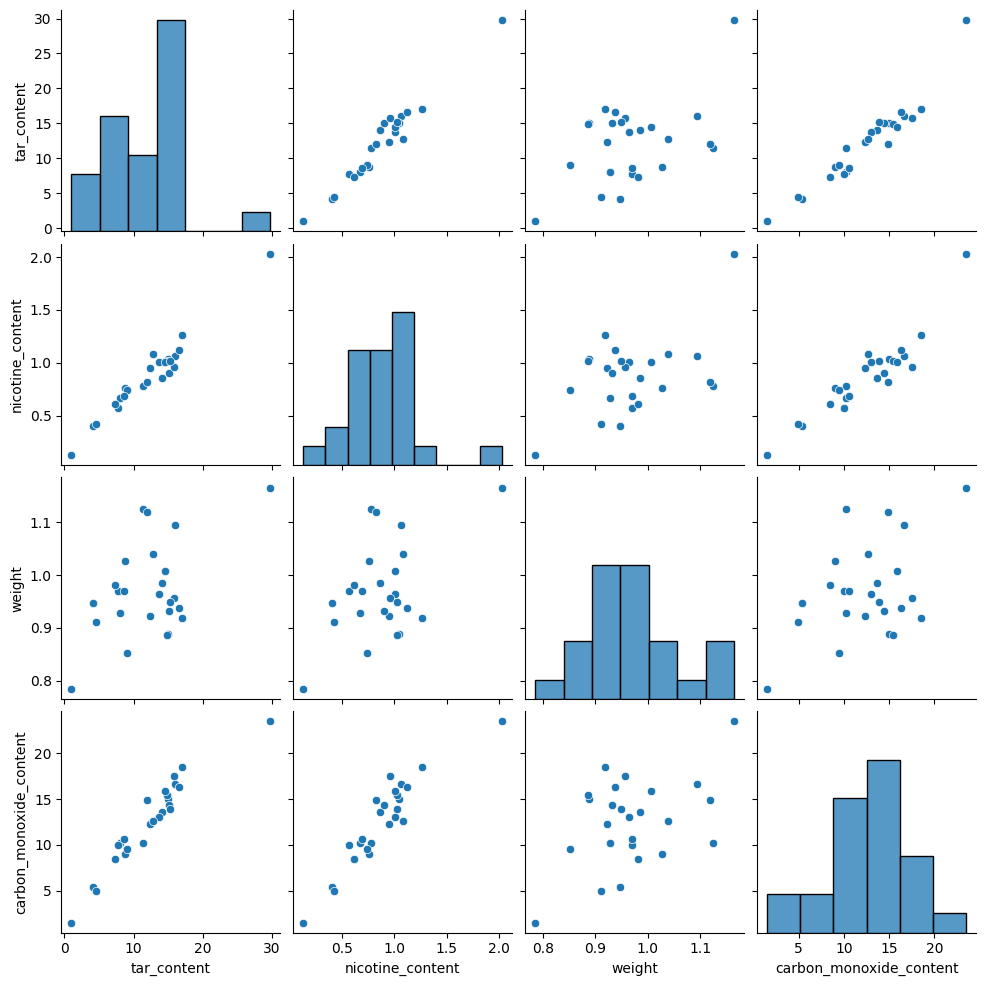

In [6]:
sns.pairplot(cigarettes)

In [7]:
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),   
    ('pca', PCA(n_components=2))
])     


In [8]:
pca_pipeline.steps

[('scaler', StandardScaler()), ('pca', PCA(n_components=2))]

<Axes: xlabel='PC2', ylabel='PC1'>

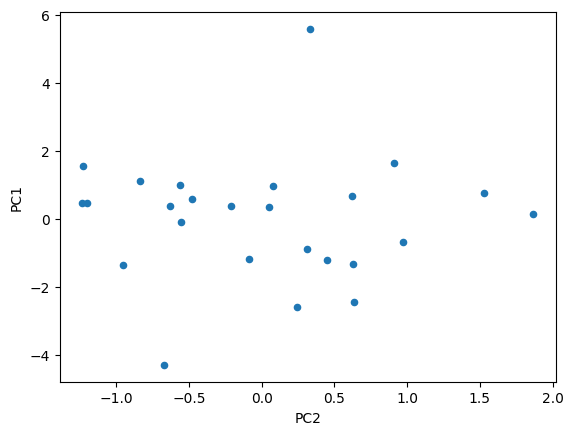

In [9]:
pca_pipeline.fit(cigarettes.select_dtypes(include=['number']))
cigarettes_pca = pca_pipeline.transform(cigarettes.select_dtypes(include=['number']))
cigarettes_pca_df = pd.DataFrame(cigarettes_pca, columns=['PC1', 'PC2'])
cigarettes_pca_df.plot.scatter(x='PC2', y='PC1')

In [10]:
from sklearn.cluster import AgglomerativeClustering, KMeans

<Axes: xlabel='PC2', ylabel='PC1'>

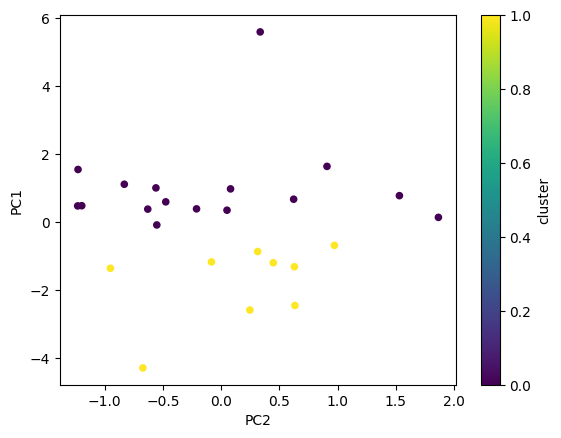

In [11]:
cluster = AgglomerativeClustering(n_clusters=2)
cigarettes_pca_df['cluster'] = cluster.fit_predict(cigarettes_pca)
cigarettes_pca_df.plot.scatter(x='PC2', y='PC1', c='cluster', cmap='viridis')

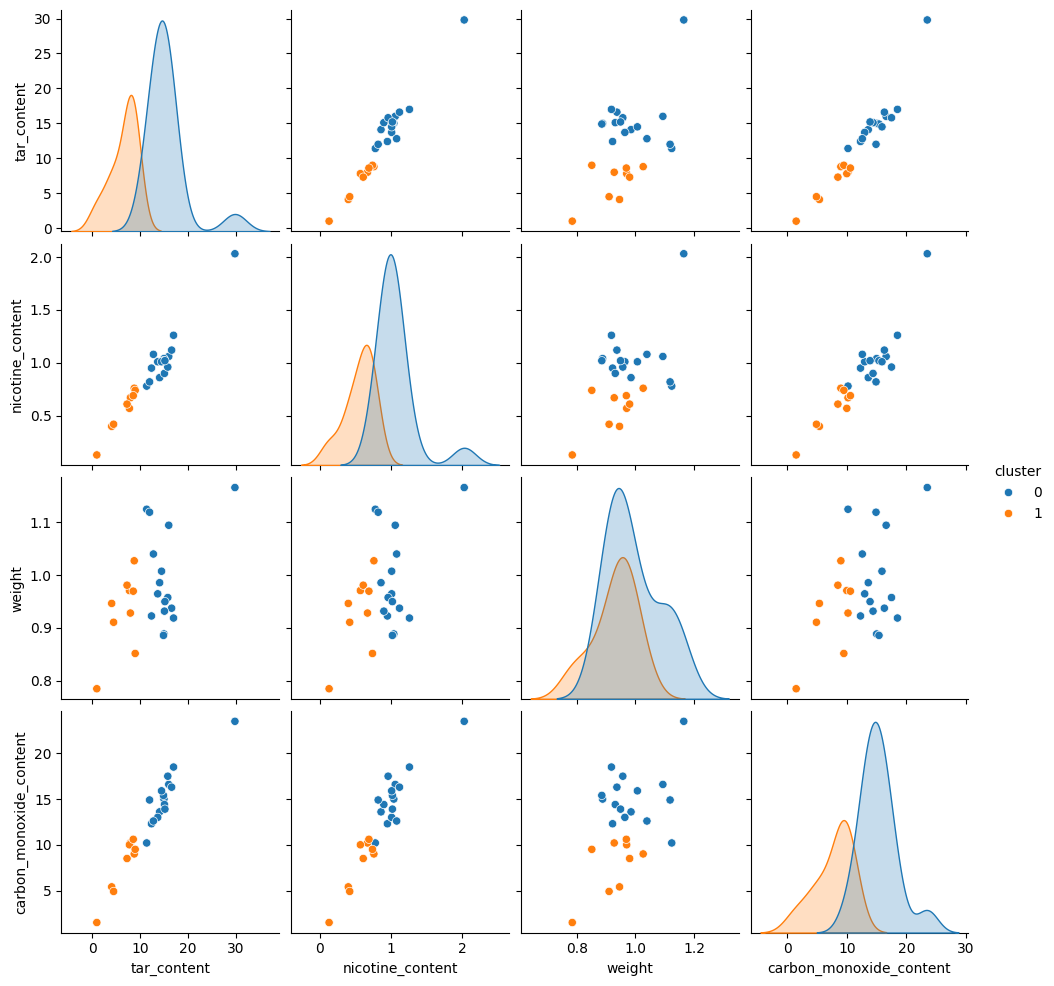

In [12]:
cigarettes['cluster'] = cigarettes_pca_df['cluster']
sns.pairplot(cigarettes, hue='cluster')

<Axes: xlabel='PC2', ylabel='PC1'>

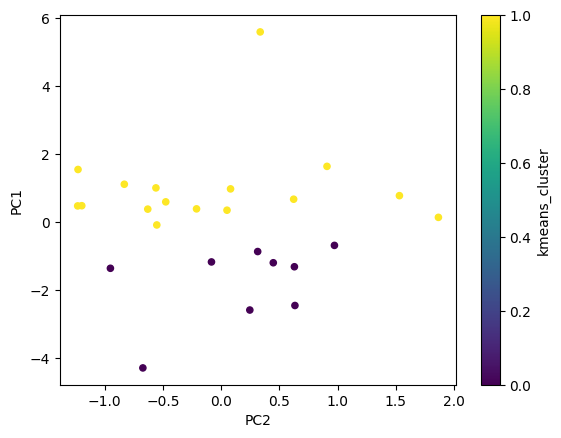

In [13]:
kmeans = KMeans(n_clusters=2, random_state=42)
cigarettes_pca_df['kmeans_cluster'] = kmeans.fit_predict(cigarettes_pca)
cigarettes_pca_df.plot.scatter(x='PC2', y='PC1', c='kmeans_cluster', cmap='viridis')

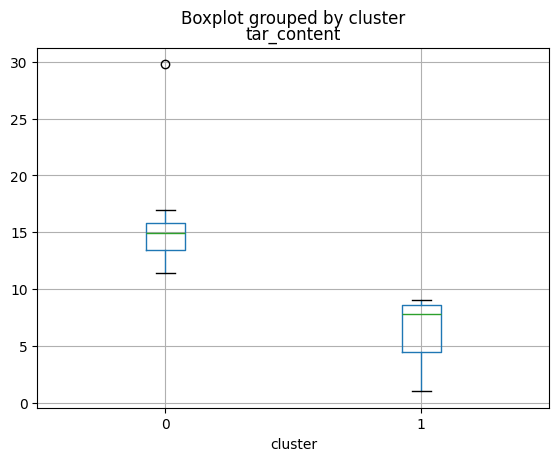

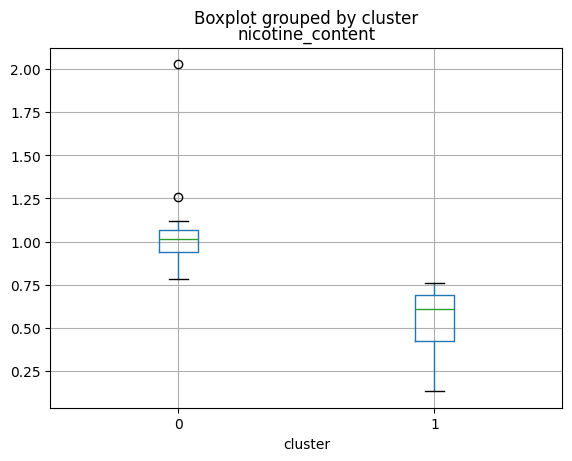

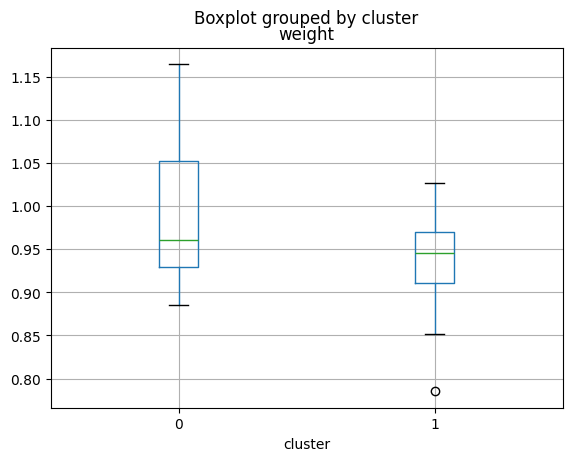

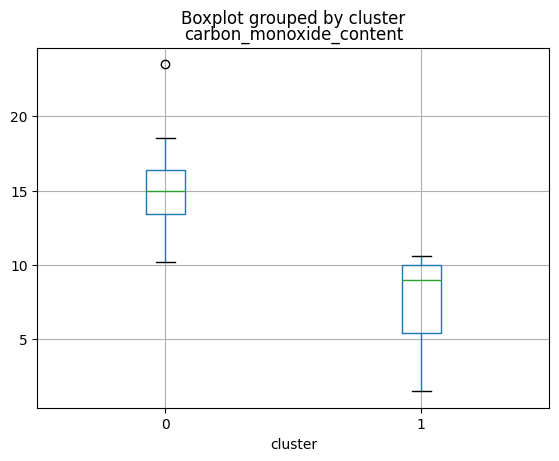

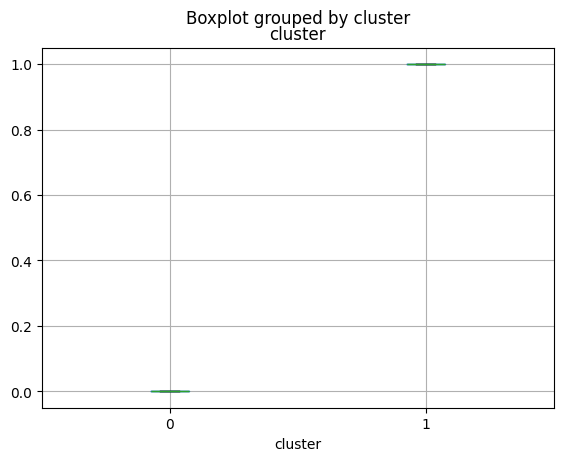

In [14]:
for col in cigarettes.columns[1:]:
    cigarettes.boxplot(column=col, by='cluster')

In [15]:
pca_pipeline.steps

[('scaler', StandardScaler()), ('pca', PCA(n_components=2))]

#  Explication de la variable "Contenu de Monoxide de Carbon"

In [ ]:
#colums_names = ['brand_name', 'tar_content', 'nicotine_content', 'weight', 'carbon_monoxide_content']
#cigarettes = pd.read_csv('cigarettes.csv', header=None, names=colums_names)

In [30]:
X = cigarettes.select_dtypes(include=['number']).drop(columns=['carbon_monoxide_content'])
y = cigarettes['carbon_monoxide_content']

def get_linear_regression_coefficients(lr, feature_names):
    coef = pd.DataFrame(lr.coef_.ravel(), index=feature_names, columns=["coef"])
    coef.loc["intercept"] = lr.intercept_
    return coef

In [31]:
lr = LinearRegression()
lr_scrores = cross_val_score(lr, X, y, cv=5)
print(f'scores: {lr_scrores}', f'mean score: {lr_scrores.mean()}')
get_linear_regression_coefficients(lr.fit(X, y), X.columns)

scores: [0.77949512 0.95407241 0.58791362 0.87100945 0.50916002] mean score: 0.7403301240714557


,coef
tar_content,0.962574
nicotine_content,-2.631661
weight,-0.130482
intercept,3.202190


In [32]:
lr_forward = LinearRegression()
sfs_forward = SequentialFeatureSelector(lr_forward, n_features_to_select="auto", direction='forward')
sfs_forward.fit(X, y)
X_forward = sfs_forward.transform(X)
lr_forward_scores = cross_val_score(lr_forward, X_forward, y, cv=5)
print(f'scores: {lr_forward_scores}', f'mean score: {lr_forward_scores.mean()}')
get_linear_regression_coefficients(lr_forward.fit(X_forward, y), X.columns[sfs_forward.get_support()])

scores: [0.79569508 0.95657851 0.71232751 0.88090493 0.67205531] mean score: 0.8035122704598224


,coef
tar_content,0.800976
intercept,2.743278


In [33]:
lr_backward = LinearRegression()
sfs_backward = SequentialFeatureSelector(lr_backward, n_features_to_select="auto", direction='backward')
sfs_backward.fit(X, y)
X_backward = sfs_backward.transform(X)
lr_backward_scores = cross_val_score(lr_backward, X_backward, y, cv=5)
print(f'scores: {lr_backward_scores}', f'mean score: {lr_backward_scores.mean()}')
get_linear_regression_coefficients(lr_backward.fit(X_backward, y), X.columns[sfs_backward.get_support()])

scores: [0.79944086 0.9689334  0.64277421 0.87125318 0.67773137] mean score: 0.7920266043498503


,coef
tar_content,0.962474
nicotine_content,-2.646272
intercept,3.089609


In [34]:
lr_positive = LinearRegression(positive=True)
lr_scores = cross_val_score(lr_positive, X, y, cv=5)
print(f'scores: {lr_scores}', f'mean score: {lr_scores.mean()}')
get_linear_regression_coefficients(lr_positive.fit(X, y), X.columns)

scores: [0.77522551 0.94220807 0.6946424  0.88090493 0.67205531] mean score: 0.7930072461826587


,coef
tar_content,0.800976
nicotine_content,0.000000
weight,0.000000
intercept,2.743278
